# 1. Data Preparation

## 1.1. Initialization and Dataset Statistics

In [2]:
import os
import zipfile
import random
import pandas as pd
import numpy as np
import torch
from google.colab import drive

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Current operating device: {device}")

drive.mount('/content/drive')

Current operating device: cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
EXTRACT_DIR = '/content/datasets'
os.makedirs(EXTRACT_DIR, exist_ok=True)

RMFD_ZIP = '/content/drive/MyDrive/face_recognition_dataset/RMFD.zip'
LFW_ZIP = '/content/drive/MyDrive/face_recognition_dataset/LFW.zip'
SMFRD_ZIP = '/content/drive/MyDrive/face_recognition_dataset/SMFRD.zip'

def extract_zip(zip_path, extract_to):
    if os.path.exists(zip_path) and not os.path.exists(extract_to):
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_to)

extract_zip(RMFD_ZIP, os.path.join(EXTRACT_DIR, 'RMFD'))
extract_zip(LFW_ZIP, os.path.join(EXTRACT_DIR, 'LFW'))
extract_zip(SMFRD_ZIP, os.path.join(EXTRACT_DIR, 'SMFRD'))

print("All datasets extracted successfully.")

All datasets extracted successfully.


In [4]:
def summarize_dataset(base_dir):
    data = []
    if not os.path.exists(base_dir):
        return data
    for root, dirs, files in os.walk(base_dir):
        if root != base_dir:
            uid = os.path.basename(root)
            num_imgs = len([f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
            if num_imgs > 0:
                data.append((uid, num_imgs))
    return data

rmfd_unmask_dir = os.path.join(EXTRACT_DIR, 'RMFD', 'AFDB_face_dataset')
rmfd_mask_dir = os.path.join(EXTRACT_DIR, 'RMFD', 'AFDB_masked_face_dataset')
lfw_dir = os.path.join(EXTRACT_DIR, 'LFW')
smfrd_dir = os.path.join(EXTRACT_DIR, 'SMFRD')

rmfd_unmask_data = summarize_dataset(rmfd_unmask_dir)
rmfd_mask_data = summarize_dataset(rmfd_mask_dir)
lfw_data = summarize_dataset(lfw_dir)
smfrd_data = summarize_dataset(smfrd_dir)

def print_stats(name, data):
    total_ids = len(data)
    total_imgs = sum(count for _, count in data)
    print(f"--- {name} ---")
    print(f"Total Identities: {total_ids}")
    print(f"Total Images: {total_imgs}")
    print("-" * 25)

print_stats("RMFD (Unmasked)", rmfd_unmask_data)
print_stats("RMFD (Masked)", rmfd_mask_data)
print_stats("LFW (Unmasked)", lfw_data)
print_stats("SMFRD (Masked)", smfrd_data)

--- RMFD (Unmasked) ---
Total Identities: 460
Total Images: 90468
-------------------------
--- RMFD (Masked) ---
Total Identities: 481
Total Images: 2203
-------------------------
--- LFW (Unmasked) ---
Total Identities: 5749
Total Images: 13233
-------------------------
--- SMFRD (Masked) ---
Total Identities: 5721
Total Images: 13115
-------------------------


## 1.2. RMFD Processing

In [5]:
import os
import random
import pandas as pd
from sklearn.model_selection import train_test_split

unmask_ids = set([item[0] for item in rmfd_unmask_data])
mask_ids = set([item[0] for item in rmfd_mask_data])
valid_ids = list(unmask_ids.intersection(mask_ids))

train_val_ids, test_ids = train_test_split(valid_ids, test_size=0.2, random_state=42)
train_ids, val_ids = train_test_split(train_val_ids, test_size=0.1, random_state=42)

print(f"Total Valid IDs: {len(valid_ids)}")
print(f"Train IDs: {len(train_ids)} | Val IDs: {len(val_ids)} | Test IDs: {len(test_ids)}")

def generate_gallery_probe(id_list, unmask_dir, mask_dir):
    gallery_data = []
    probe_data = []

    for idx, uid in enumerate(id_list):
        label = idx
        uid_unmask_dir = os.path.join(unmask_dir, uid)
        uid_mask_dir = os.path.join(mask_dir, uid)

        if os.path.exists(uid_unmask_dir):
            for f in os.listdir(uid_unmask_dir):
                if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                    gallery_data.append([os.path.join(uid_unmask_dir, f), label])

        if os.path.exists(uid_mask_dir):
            for f in os.listdir(uid_mask_dir):
                if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                    probe_data.append([os.path.join(uid_mask_dir, f), label])

    return pd.DataFrame(gallery_data, columns=['img_path', 'label']), pd.DataFrame(probe_data, columns=['img_path', 'label'])

df_val_gallery, df_val_probe = generate_gallery_probe(val_ids, rmfd_unmask_dir, rmfd_mask_dir)
df_test_gallery, df_test_probe = generate_gallery_probe(test_ids, rmfd_unmask_dir, rmfd_mask_dir)

df_val_gallery.to_csv('/content/drive/MyDrive/face_recognition_dataset/RMFD_val_gallery.csv', index=False)
df_val_probe.to_csv('/content/drive/MyDrive/face_recognition_dataset/RMFD_val_probe.csv', index=False)
df_test_gallery.to_csv('/content/drive/MyDrive/face_recognition_dataset/RMFD_test_gallery.csv', index=False)
df_test_probe.to_csv('/content/drive/MyDrive/face_recognition_dataset/RMFD_test_probe.csv', index=False)

print(f"Val Gallery: {len(df_val_gallery)} imgs | Val Probe: {len(df_val_probe)} imgs")
print(f"Test Gallery: {len(df_test_gallery)} imgs | Test Probe: {len(df_test_probe)} imgs")

Total Valid IDs: 403
Train IDs: 289 | Val IDs: 33 | Test IDs: 81
Val Gallery: 6665 imgs | Val Probe: 179 imgs
Test Gallery: 16277 imgs | Test Probe: 370 imgs


## 1.3. SMFRD and LFW Processing

In [6]:
lfw_ids = set([item[0] for item in lfw_data])
smfrd_ids = set([item[0] for item in smfrd_data])
valid_sim_ids = list(lfw_ids.intersection(smfrd_ids))

sim_train_ids, sim_val_ids = train_test_split(valid_sim_ids, test_size=0.1, random_state=42)

print(f"Total Valid Simulated IDs: {len(valid_sim_ids)}")
print(f"Simulated Train IDs: {len(sim_train_ids)} | Simulated Val IDs: {len(sim_val_ids)}")

df_sim_val_gallery, df_sim_val_probe = generate_gallery_probe(sim_val_ids, lfw_dir, smfrd_dir)

df_sim_val_gallery.to_csv('/content/drive/MyDrive/face_recognition_dataset/Simulated_val_gallery.csv', index=False)
df_sim_val_probe.to_csv('/content/drive/MyDrive/face_recognition_dataset/Simulated_val_probe.csv', index=False)

print(f"Simulated Val Gallery: {len(df_sim_val_gallery)} imgs | Simulated Val Probe: {len(df_sim_val_probe)} imgs")

Total Valid Simulated IDs: 5721
Simulated Train IDs: 5148 | Simulated Val IDs: 573
Simulated Val Gallery: 1430 imgs | Simulated Val Probe: 1403 imgs


## 1.4. Data Loaders

In [7]:
import os
from PIL import Image

def get_image_dimensions(directory):
    widths = []
    heights = []
    for root, _, files in os.walk(directory):
        for f in files:
            if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                try:
                    img_path = os.path.join(root, f)
                    with Image.open(img_path) as img:
                        w, h = img.size
                        widths.append(w)
                        heights.append(h)
                except:
                    pass
    if not widths:
        return 0, 0, 0, 0, 0, 0
    return min(widths), max(widths), sum(widths)//len(widths), min(heights), max(heights), sum(heights)//len(heights)

datasets_to_check = {
    "RMFD (Unmasked)": os.path.join(EXTRACT_DIR, 'RMFD', 'AFDB_face_dataset'),
    "RMFD (Masked)": os.path.join(EXTRACT_DIR, 'RMFD', 'AFDB_masked_face_dataset'),
    "LFW (Unmasked)": os.path.join(EXTRACT_DIR, 'LFW'),
    "SMFRD (Masked)": os.path.join(EXTRACT_DIR, 'SMFRD')
}

for name, path in datasets_to_check.items():
    min_w, max_w, avg_w, min_h, max_h, avg_h = get_image_dimensions(path)
    print(f"--- {name} ---")
    print(f"Width : Min = {min_w}px, Max = {max_w}px, Average = {avg_w}px")
    print(f"Height: Min = {min_h}px, Max = {max_h}px, Average = {avg_h}px")
    print("-" * 30)

--- RMFD (Unmasked) ---
Width : Min = 10px, Max = 160px, Average = 146px
Height: Min = 12px, Max = 160px, Average = 132px
------------------------------
--- RMFD (Masked) ---
Width : Min = 18px, Max = 1508px, Average = 139px
Height: Min = 20px, Max = 1606px, Average = 193px
------------------------------
--- LFW (Unmasked) ---
Width : Min = 250px, Max = 250px, Average = 250px
Height: Min = 250px, Max = 250px, Average = 250px
------------------------------
--- SMFRD (Masked) ---
Width : Min = 128px, Max = 128px, Average = 128px
Height: Min = 128px, Max = 128px, Average = 128px
------------------------------


In [8]:
import os
import glob
import random
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

base_csv_path = '/content/drive/MyDrive/face_recognition_dataset/'

rmfd_unmask_dir = '/content/datasets/RMFD/AFDB_face_dataset'
rmfd_mask_dir = '/content/datasets/RMFD/AFDB_masked_face_dataset'
lfw_dir = '/content/datasets/LFW'
smfrd_dir = '/content/datasets/SMFRD'

rmfd_train_df = pd.read_csv(os.path.join(base_csv_path, 'RMFD_train.csv'))
train_ids = rmfd_train_df['mask_path'].apply(lambda x: os.path.basename(os.path.dirname(x))).unique().tolist()

sim_train_df = pd.read_csv(os.path.join(base_csv_path, 'Simulated_train.csv'))
sim_train_ids = sim_train_df['mask_path'].apply(lambda x: os.path.basename(os.path.dirname(x))).unique().tolist()

class FaceTrainDatasetDynamic(Dataset):
    def __init__(self, unmask_dir, mask_dir, id_list, k=1, mask_transform=None, nomask_transform=None):
        self.unmask_dir = unmask_dir
        self.mask_dir = mask_dir
        self.id_list = id_list
        self.k = k
        self.mask_transform = mask_transform
        self.nomask_transform = nomask_transform
        self.epoch = 0
        self.id_to_mask_imgs = {}
        self.id_to_unmask_imgs = {}
        self.label_map = {uid: idx for idx, uid in enumerate(id_list)}

        for uid in id_list:
            mask_imgs = glob.glob(os.path.join(mask_dir, uid, '*.*'))
            unmask_imgs = glob.glob(os.path.join(unmask_dir, uid, '*.*'))
            if len(mask_imgs) >= 1 and len(unmask_imgs) >= 1:
                self.id_to_mask_imgs[uid] = mask_imgs
                self.id_to_unmask_imgs[uid] = unmask_imgs

        self.valid_ids = list(self.id_to_mask_imgs.keys())
        self.pairs = []
        self._rebuild_pairs()

    def set_epoch(self, epoch):
        self.epoch = epoch
        self._rebuild_pairs()

    def _rebuild_pairs(self):
        rng = random.Random(self.epoch * 42)
        self.pairs = []
        for uid in self.valid_ids:
            mask_imgs = self.id_to_mask_imgs[uid]
            unmask_imgs = self.id_to_unmask_imgs[uid]
            label = self.label_map[uid]
            for m_img in mask_imgs:
                k_val = min(len(unmask_imgs), self.k)
                sampled = rng.sample(unmask_imgs, k_val)
                for u_img in sampled:
                    self.pairs.append((m_img, u_img, label))
        rng.shuffle(self.pairs)

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        mask_path, nomask_path, label = self.pairs[idx]
        mask_img = Image.open(mask_path).convert('RGB')
        nomask_img = Image.open(nomask_path).convert('RGB')
        if self.mask_transform:
            mask_img = self.mask_transform(mask_img)
        if self.nomask_transform:
            nomask_img = self.nomask_transform(nomask_img)
        return mask_img, nomask_img, label

class FaceImageDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.df = pd.read_csv(csv_file)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['img_path']
        label = int(self.df.iloc[idx]['label'])
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label

mask_train_transform = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

nomask_train_transform = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

eval_transform = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

rmfd_train_ds = FaceTrainDatasetDynamic(
    rmfd_unmask_dir, rmfd_mask_dir, train_ids, k=3,
    mask_transform=mask_train_transform,
    nomask_transform=nomask_train_transform
)

rmfd_val_gallery_ds   = FaceImageDataset(os.path.join(base_csv_path, 'RMFD_val_gallery.csv'),   eval_transform)
rmfd_val_probe_ds     = FaceImageDataset(os.path.join(base_csv_path, 'RMFD_val_probe.csv'),     eval_transform)
rmfd_test_gallery_ds  = FaceImageDataset(os.path.join(base_csv_path, 'RMFD_test_gallery.csv'),  eval_transform)
rmfd_test_probe_ds    = FaceImageDataset(os.path.join(base_csv_path, 'RMFD_test_probe.csv'),    eval_transform)

sim_train_ds = FaceTrainDatasetDynamic(
    lfw_dir, smfrd_dir, sim_train_ids, k=3,
    mask_transform=mask_train_transform,
    nomask_transform=nomask_train_transform
)

sim_val_gallery_ds = FaceImageDataset(os.path.join(base_csv_path, 'Simulated_val_gallery.csv'), eval_transform)
sim_val_probe_ds   = FaceImageDataset(os.path.join(base_csv_path, 'Simulated_val_probe.csv'),   eval_transform)

BATCH_SIZE = 64

rmfd_train_loader        = DataLoader(rmfd_train_ds,        batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
rmfd_val_gallery_loader  = DataLoader(rmfd_val_gallery_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
rmfd_val_probe_loader    = DataLoader(rmfd_val_probe_ds,    batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
rmfd_test_gallery_loader = DataLoader(rmfd_test_gallery_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
rmfd_test_probe_loader   = DataLoader(rmfd_test_probe_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

sim_train_loader       = DataLoader(sim_train_ds,       batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
sim_val_gallery_loader = DataLoader(sim_val_gallery_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
sim_val_probe_loader   = DataLoader(sim_val_probe_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

sample_mask, sample_nomask, sample_label = next(iter(rmfd_train_loader))

print(f"RMFD Train Dataset Length: {len(rmfd_train_ds)} pairs")
print(f"RMFD Val Dataset Length: {len(rmfd_val_gallery_ds)} gallery imgs, {len(rmfd_val_probe_ds)} probe imgs")
print(f"RMFD Test Dataset Length: {len(rmfd_test_gallery_ds)} gallery imgs, {len(rmfd_test_probe_ds)} probe imgs")
print(f"Simulated Train Dataset Length: {len(sim_train_ds)} pairs")
print(f"Simulated Val Dataset Length: {len(sim_val_gallery_ds)} gallery imgs, {len(sim_val_probe_ds)} probe imgs")
print(f"Batch Image Shape: {sample_mask.shape}")
print(f"Batch Label Shape: {sample_label.shape}")

RMFD Train Dataset Length: 4191 pairs
RMFD Val Dataset Length: 6665 gallery imgs, 179 probe imgs
RMFD Test Dataset Length: 16277 gallery imgs, 370 probe imgs
Simulated Train Dataset Length: 26116 pairs
Simulated Val Dataset Length: 1430 gallery imgs, 1403 probe imgs
Batch Image Shape: torch.Size([64, 3, 112, 112])
Batch Label Shape: torch.Size([64])


#2. Model Definition

##2.1. CoordAtt Module

In [9]:
import torch
import torch.nn as nn

class h_sigmoid(nn.Module):
    def __init__(self, inplace=True):
        super(h_sigmoid, self).__init__()
        self.relu = nn.ReLU6(inplace=inplace)

    def forward(self, x):
        return self.relu(x + 3) / 6

class h_swish(nn.Module):
    def __init__(self, inplace=True):
        super(h_swish, self).__init__()
        self.sigmoid = h_sigmoid(inplace=inplace)

    def forward(self, x):
        return x * self.sigmoid(x)

class CoordAtt(nn.Module):
    def __init__(self, inp, oup, reduction=32):
        super(CoordAtt, self).__init__()
        self.pool_h = nn.AdaptiveAvgPool2d((None, 1))
        self.pool_w = nn.AdaptiveAvgPool2d((1, None))
        mip = max(8, inp // reduction)
        self.conv1 = nn.Conv2d(inp, mip, kernel_size=1, stride=1, padding=0)
        self.bn1 = nn.BatchNorm2d(mip)
        self.act = h_swish()
        self.conv_h = nn.Conv2d(mip, oup, kernel_size=1, stride=1, padding=0)
        self.conv_w = nn.Conv2d(mip, oup, kernel_size=1, stride=1, padding=0)

    def forward(self, x):
        identity = x
        n, c, h, w = x.size()
        x_h = self.pool_h(x)
        x_w = self.pool_w(x).permute(0, 1, 3, 2)
        y = torch.cat([x_h, x_w], dim=2)
        y = self.conv1(y)
        y = self.bn1(y)
        y = self.act(y)
        x_h, x_w = torch.split(y, [h, w], dim=2)
        x_w = x_w.permute(0, 1, 3, 2)
        a_h = self.conv_h(x_h).sigmoid()
        a_w = self.conv_w(x_w).sigmoid()
        return identity * a_h * a_w

##2.2. IR-50 + CoordAtt Backbone

In [10]:
import torch
import torch.nn as nn
from torch.nn import Dropout, Sequential, Linear, BatchNorm1d, BatchNorm2d, Conv2d, PReLU, MaxPool2d, Flatten
from huggingface_hub import hf_hub_download

class BasicBlockIR(nn.Module):
    def __init__(self, in_channel, depth, stride):
        super(BasicBlockIR, self).__init__()
        if in_channel == depth:
            self.shortcut_layer = MaxPool2d(1, stride)
        else:
            self.shortcut_layer = Sequential(
                Conv2d(in_channel, depth, (1, 1), stride, bias=False),
                BatchNorm2d(depth)
            )
        self.res_layer = Sequential(
            BatchNorm2d(in_channel),
            Conv2d(in_channel, depth, (3, 3), (1, 1), 1, bias=False),
            BatchNorm2d(depth),
            PReLU(depth),
            Conv2d(depth, depth, (3, 3), stride, 1, bias=False),
            BatchNorm2d(depth)
        )

    def forward(self, x):
        return self.res_layer(x) + self.shortcut_layer(x)


def get_blocks():
    return [
        [(64,  64,  2)] + [(64,  64,  1)] * 2,
        [(64,  128, 2)] + [(128, 128, 1)] * 3,
        [(128, 256, 2)] + [(256, 256, 1)] * 13,
        [(256, 512, 2)] + [(512, 512, 1)] * 2,
    ]


class IR50CoordAtt(nn.Module):
    def __init__(self, embedding_size=512):
        super(IR50CoordAtt, self).__init__()

        self.input_layer = Sequential(
            Conv2d(3, 64, (3, 3), 1, 1, bias=False),
            BatchNorm2d(64),
            PReLU(64)
        )

        blocks = get_blocks()
        modules = []
        for stage in blocks:
            for (in_c, depth, stride) in stage:
                modules.append(BasicBlockIR(in_c, depth, stride))
        self.body = Sequential(*modules)

        self.ca = CoordAtt(512, 512)

        self.output_layer = Sequential(
            BatchNorm2d(512),
            Dropout(0.4),
            Flatten(),
            Linear(512 * 7 * 7, embedding_size),
            BatchNorm1d(embedding_size, affine=False)
        )

    def forward(self, x):
        x = self.input_layer(x)
        x = self.body(x)
        x = self.ca(x)
        x = self.output_layer(x)
        return x


def get_backbone_model(embedding_size=512, pretrained=True):
    model = IR50CoordAtt(embedding_size)

    if pretrained:
        model_pt_path = hf_hub_download(
            repo_id='minchul/cvlface_adaface_ir50_ms1mv2',
            filename='pretrained_model/model.pt',
            cache_dir='/content/drive/MyDrive/Model_Weights/pretrain'
        )
        state_dict = torch.load(model_pt_path, map_location='cpu')
        state_dict = {k.replace('net.', ''): v for k, v in state_dict.items()}
        missing, unexpected = model.load_state_dict(state_dict, strict=False)
        print(f"Missing keys (expected = CoordAtt only): {missing}")
        print(f"Unexpected keys (expected = empty): {unexpected}")

    return model


if __name__ == "__main__":
    import torchsummary
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    backbone = get_backbone_model(pretrained=True).to(device)
    torchsummary.summary(backbone, (3, 112, 112))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Missing keys (expected = CoordAtt only): ['ca.conv1.weight', 'ca.conv1.bias', 'ca.bn1.weight', 'ca.bn1.bias', 'ca.bn1.running_mean', 'ca.bn1.running_var', 'ca.conv_h.weight', 'ca.conv_h.bias', 'ca.conv_w.weight', 'ca.conv_w.bias']
Unexpected keys (expected = empty): []
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           1,728
       BatchNorm2d-2         [-1, 64, 112, 112]             128
             PReLU-3         [-1, 64, 112, 112]              64
       BatchNorm2d-4         [-1, 64, 112, 112]             128
            Conv2d-5         [-1, 64, 112, 112]          36,864
       BatchNorm2d-6         [-1, 64, 112, 112]             128
             PReLU-7         [-1, 64, 112, 112]              64
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
        MaxPool2d-10     

##2.3. AdaFace và ArcFace Layers

In [11]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

class ArcFaceLayer(nn.Module):
    def __init__(self, in_features, out_features, s=64.0, m=0.50):
        super(ArcFaceLayer, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.s = s
        self.m = m
        self.weight = nn.Parameter(torch.FloatTensor(out_features, in_features))
        nn.init.xavier_uniform_(self.weight)
        self.cos_m = math.cos(m)
        self.sin_m = math.sin(m)
        self.th = math.cos(math.pi - m)
        self.mm = math.sin(math.pi - m) * m

    def forward(self, input, label):
        cosine = F.linear(F.normalize(input, p=2, dim=1), F.normalize(self.weight, p=2, dim=1))
        sine = torch.sqrt(1.0 - torch.pow(cosine, 2))
        phi = cosine * self.cos_m - sine * self.sin_m
        phi = torch.where(cosine > self.th, phi, cosine - self.mm)
        one_hot = torch.zeros(cosine.size(), device=input.device)
        one_hot.scatter_(1, label.view(-1, 1).long(), 1)
        output = (one_hot * phi) + ((1.0 - one_hot) * cosine)
        output *= self.s
        return output

class AdaFaceLayer(nn.Module):
    def __init__(self, in_features, out_features, m=0.4, h=0.333, s=64.0):
        super(AdaFaceLayer, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.s = s
        self.m = m
        self.eps = 1e-3
        self.h = h
        self.weight = nn.Parameter(torch.FloatTensor(out_features, in_features))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, input, label):
        norms = torch.norm(input, p=2, dim=1, keepdim=True)
        norms_batch = norms.clone().detach()
        safe_norms = torch.clamp(norms_batch, min=self.eps, max=100)
        margin_scaler = (safe_norms - safe_norms.mean()) / (safe_norms.std() + self.eps)
        margin_scaler = margin_scaler * self.h
        margin_scaler = torch.clamp(margin_scaler, -1, 1)
        cosine = F.linear(F.normalize(input, p=2, dim=1), F.normalize(self.weight, p=2, dim=1))
        m_arc = torch.zeros(label.size()[0], cosine.size()[1], device=cosine.device)
        m_arc.scatter_(1, label.view(-1, 1).long(), 1.0)
        g_angular = self.m * margin_scaler * -1
        m_arc = m_arc * g_angular
        theta = cosine.acos()
        theta_m = torch.clamp(theta + m_arc, min=self.eps, max=math.pi - self.eps)
        cosine_m = theta_m.cos()
        m_add = torch.zeros(label.size()[0], cosine.size()[1], device=cosine.device)
        m_add.scatter_(1, label.view(-1, 1).long(), self.m)
        g_add = self.m * margin_scaler + self.m
        m_add = m_add * g_add
        cosine_m = cosine_m - m_add
        output = cosine_m * self.s
        return output

print("ArcFace and AdaFace layers initialized.")

ArcFace and AdaFace layers initialized.


##2.4. Full Architecture Vizualization

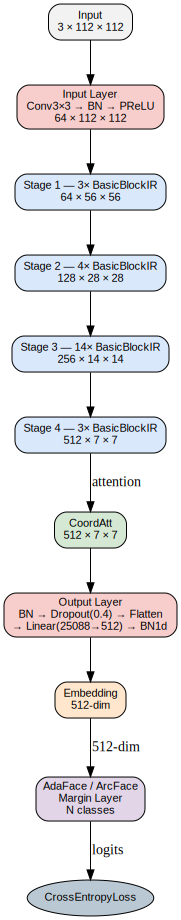

In [12]:
!apt-get install -y graphviz > /dev/null 2>&1
!pip install graphviz -q

from graphviz import Digraph
from IPython.display import display

g = Digraph(name='IR50CoordAtt', format='png')
g.attr(rankdir='TB', splines='ortho', nodesep='0.4', ranksep='0.6')
g.attr('node', shape='box', style='filled,rounded', fontname='Helvetica', fontsize='11')

g.node('input',        'Input\n3 × 112 × 112',              fillcolor='#F2F2F2')
g.node('input_layer',  'Input Layer\nConv3×3 → BN → PReLU\n64 × 112 × 112', fillcolor='#F8CECC')
g.node('stage1',       'Stage 1 — 3× BasicBlockIR\n64 × 56 × 56',           fillcolor='#DAE8FC')
g.node('stage2',       'Stage 2 — 4× BasicBlockIR\n128 × 28 × 28',          fillcolor='#DAE8FC')
g.node('stage3',       'Stage 3 — 14× BasicBlockIR\n256 × 14 × 14',         fillcolor='#DAE8FC')
g.node('stage4',       'Stage 4 — 3× BasicBlockIR\n512 × 7 × 7',            fillcolor='#DAE8FC')
g.node('ca',           'CoordAtt\n512 × 7 × 7',                              fillcolor='#D5E8D4')
g.node('output_layer', 'Output Layer\nBN → Dropout(0.4) → Flatten\n→ Linear(25088→512) → BN1d', fillcolor='#F8CECC')
g.node('embedding',    'Embedding\n512-dim',                                 fillcolor='#FFE6CC')
g.node('margin',       'AdaFace / ArcFace\nMargin Layer\nN classes',         fillcolor='#E1D5E7')
g.node('loss',         'CrossEntropyLoss',                                   fillcolor='#BAC8D3', shape='ellipse')

g.edge('input',        'input_layer')
g.edge('input_layer',  'stage1')
g.edge('stage1',       'stage2')
g.edge('stage2',       'stage3')
g.edge('stage3',       'stage4')
g.edge('stage4',       'ca',           label=' attention')
g.edge('ca',           'output_layer')
g.edge('output_layer', 'embedding')
g.edge('embedding',    'margin',       label=' 512-dim')
g.edge('margin',       'loss',         label=' logits')

display(g)

#3. Training

##3.1. Training Setup

In [13]:
import torch
import torch.nn.functional as F
from tqdm import tqdm

def train_model(model, margin_layer, train_loader, val_gallery_loader, val_probe_loader,
                criterion, optimizer, scheduler, num_epochs, device, save_path):

    best_rank1 = 0.0
    history = {'train_loss': [], 'train_acc': [], 'val_rank1': []}
    scaler = torch.amp.GradScaler('cuda')

    for epoch in range(num_epochs):
        model.train()
        margin_layer.train()

        running_loss = 0.0
        correct = 0
        total = 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)

        for mask_imgs, nomask_imgs, labels in pbar:
            mask_imgs  = mask_imgs.to(device)
            nomask_imgs = nomask_imgs.to(device)
            labels     = labels.to(device)

            optimizer.zero_grad()

            with torch.amp.autocast('cuda'):
                mask_embs   = model(mask_imgs)
                nomask_embs = model(nomask_imgs)

                outputs_mask   = margin_layer(mask_embs, labels)
                outputs_nomask = margin_layer(nomask_embs, labels)

                loss = (criterion(outputs_mask, labels) + criterion(outputs_nomask, labels)) / 2.0

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            batch_size = labels.size(0)
            running_loss += loss.item() * batch_size * 2
            total += batch_size * 2

            _, pred_mask   = outputs_mask.max(1)
            _, pred_nomask = outputs_nomask.max(1)
            correct += pred_mask.eq(labels).sum().item() + pred_nomask.eq(labels).sum().item()

            pbar.set_postfix({'Loss': f"{loss.item():.3f}", 'Acc': f"{100.*correct/total:.2f}%"})

        train_loader.dataset.set_epoch(epoch + 1)
        scheduler.step()

        epoch_loss = running_loss / total
        epoch_acc  = correct / total
        val_rank1  = evaluate_1_to_N(model, val_gallery_loader, val_probe_loader, device)

        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_acc)
        history['val_rank1'].append(val_rank1)

        print(f"\nEpoch {epoch+1} Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc*100:.2f}% | Val Rank-1: {val_rank1*100:.2f}%")

        if val_rank1 > best_rank1:
            best_rank1 = val_rank1
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'margin_state_dict': margin_layer.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_rank1': best_rank1
            }, save_path)
            print(f"New Best Model Saved: {save_path}")

    return history


@torch.no_grad()
def evaluate_1_to_N(model, gallery_loader, probe_loader, device):
    model.eval()

    gallery_embs = []
    gallery_lbls = []
    for imgs, labels in tqdm(gallery_loader, desc="Extracting Gallery", leave=False):
        imgs   = imgs.to(device)
        labels = labels.to(device)
        with torch.amp.autocast('cuda'):
            embs = F.normalize(model(imgs), p=2, dim=1)
        gallery_embs.append(embs)
        gallery_lbls.append(labels)

    gallery_embs = torch.cat(gallery_embs, dim=0)
    gallery_lbls = torch.cat(gallery_lbls, dim=0)

    unique_labels = torch.unique(gallery_lbls)
    mean_gallery_embs = []
    for lbl in unique_labels:
        mask = (gallery_lbls == lbl)
        mean_emb = F.normalize(gallery_embs[mask].mean(dim=0, keepdim=True), p=2, dim=1)
        mean_gallery_embs.append(mean_emb)
    mean_gallery_embs = torch.cat(mean_gallery_embs, dim=0)

    probe_embs = []
    probe_lbls = []
    for imgs, labels in tqdm(probe_loader, desc="Extracting Probes", leave=False):
        imgs   = imgs.to(device)
        labels = labels.to(device)
        with torch.amp.autocast('cuda'):
            embs = F.normalize(model(imgs), p=2, dim=1)
        probe_embs.append(embs)
        probe_lbls.append(labels)

    probe_embs = torch.cat(probe_embs, dim=0)
    probe_lbls = torch.cat(probe_lbls, dim=0)

    sim_matrix    = torch.matmul(probe_embs, mean_gallery_embs.T)
    _, top1_idx   = torch.max(sim_matrix, dim=1)
    predicted_lbls = unique_labels[top1_idx]

    rank1 = (predicted_lbls == probe_lbls).float().mean().item()
    return rank1

## 3.2. Model 1: RMFD with AdaFace

Missing keys (expected = CoordAtt only): ['ca.conv1.weight', 'ca.conv1.bias', 'ca.bn1.weight', 'ca.bn1.bias', 'ca.bn1.running_mean', 'ca.bn1.running_var', 'ca.conv_h.weight', 'ca.conv_h.bias', 'ca.conv_w.weight', 'ca.conv_w.bias']
Unexpected keys (expected = empty): []



Epoch 1 Train Loss: 17.5929 | Train Acc: 1.05% | Val Rank-1: 31.28%
New Best Model Saved: /content/drive/MyDrive/Model_Weights/model1_rmfd_adaface.pth



Epoch 2 Train Loss: 13.2507 | Train Acc: 7.23% | Val Rank-1: 29.61%



Epoch 3 Train Loss: 10.2076 | Train Acc: 17.00% | Val Rank-1: 37.99%
New Best Model Saved: /content/drive/MyDrive/Model_Weights/model1_rmfd_adaface.pth



Epoch 4 Train Loss: 7.8568 | Train Acc: 30.09% | Val Rank-1: 46.37%
New Best Model Saved: /content/drive/MyDrive/Model_Weights/model1_rmfd_adaface.pth


...


Epoch 36 Train Loss: 1.1331 | Train Acc: 88.63% | Val Rank-1: 86.03%



Epoch 37 Train Loss: 1.0645 | Train Acc: 89.11% | Val Rank-1: 85.47%



Epoch 38 Train Loss: 1.1024 | Train Acc: 88.79% | Val Rank-1: 86.03%



Epoch 39 Train Loss: 1.0792 | Train Acc: 88.86% | Val Rank-1: 85.47%



Epoch 40 Train Loss: 1.1108 | Train Acc: 89.04% | Val Rank-1: 85.47%


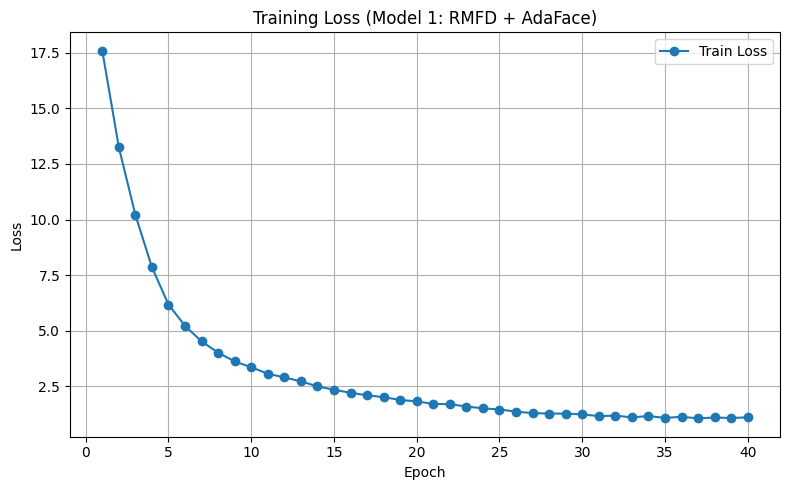

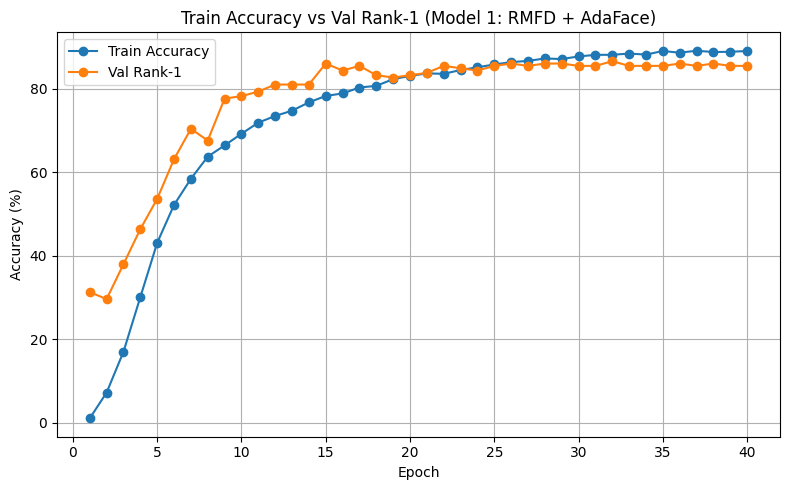

In [15]:
import os
import gc
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
import matplotlib.pyplot as plt

gc.collect()
torch.cuda.empty_cache()

save_dir = '/content/drive/MyDrive/Model_Weights'
os.makedirs(save_dir, exist_ok=True)
save_path_m1 = os.path.join(save_dir, 'model1_rmfd_adaface.pth')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_classes_m1 = len(train_ids)

model1 = get_backbone_model(pretrained=True).to(device)
model1_adaface = AdaFaceLayer(in_features=512, out_features=num_classes_m1).to(device)

criterion_m1 = nn.CrossEntropyLoss().to(device)

optimizer_m1 = optim.SGD([
    {'params': model1.parameters()},
    {'params': model1_adaface.parameters()}
], lr=0.001, momentum=0.9, weight_decay=5e-4)

scheduler_m1 = CosineAnnealingLR(optimizer_m1, T_max=40, eta_min=1e-5)

history_m1 = train_model(
    model=model1,
    margin_layer=model1_adaface,
    train_loader=rmfd_train_loader,
    val_gallery_loader=rmfd_val_gallery_loader,
    val_probe_loader=rmfd_val_probe_loader,
    criterion=criterion_m1,
    optimizer=optimizer_m1,
    scheduler=scheduler_m1,
    num_epochs=40,
    device=device,
    save_path=save_path_m1
)

def plot_training_results(history, title_suffix=""):
    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history['train_loss'], label="Train Loss", marker='o')
    plt.title(f"Training Loss {title_suffix}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, [a * 100 for a in history['train_acc']], label="Train Accuracy", marker='o')
    plt.plot(epochs, [a * 100 for a in history['val_rank1']], label="Val Rank-1", marker='o')
    plt.title(f"Train Accuracy vs Val Rank-1 {title_suffix}")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_training_results(history_m1, "(Model 1: RMFD + AdaFace)")

=== RMFD TEST EVALUATION RESULTS ===
Rank-1 Accuracy : 64.32%
Rank-5 Accuracy : 72.70%
Rank-10 Accuracy: 77.57%


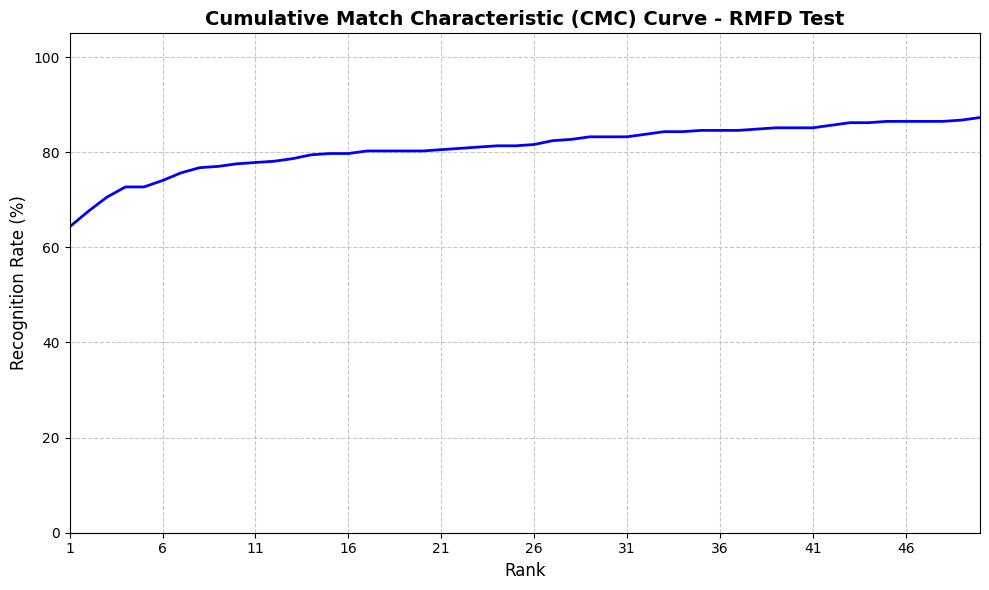

In [16]:
"""## 4.1. CMC Curve & Rank-1 (RMFD Test)"""

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

checkpoint = torch.load(save_path_m1, weights_only=False)
model1.load_state_dict(checkpoint['model_state_dict'])
model1.eval()

gallery_embs = []
gallery_lbls = []
with torch.no_grad():
    for imgs, labels in rmfd_test_gallery_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        with torch.amp.autocast('cuda'):
            embs = F.normalize(model1(imgs), p=2, dim=1)
        gallery_embs.append(embs)
        gallery_lbls.append(labels)

gallery_embs = torch.cat(gallery_embs, dim=0)
gallery_lbls = torch.cat(gallery_lbls, dim=0)

probe_embs = []
probe_lbls = []
with torch.no_grad():
    for imgs, labels in rmfd_test_probe_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        with torch.amp.autocast('cuda'):
            embs = F.normalize(model1(imgs), p=2, dim=1)
        probe_embs.append(embs)
        probe_lbls.append(labels)

probe_embs = torch.cat(probe_embs, dim=0)
probe_lbls = torch.cat(probe_lbls, dim=0)

sim_matrix = torch.matmul(probe_embs, gallery_embs.T)
sorted_indices = torch.argsort(sim_matrix, dim=1, descending=True)
sorted_labels = gallery_lbls[sorted_indices]
correct_ranks = (sorted_labels == probe_lbls.unsqueeze(1))

def calculate_rank_k(correct_matrix, k):
    return correct_matrix[:, :k].any(dim=1).float().mean().item()

rank1_acc  = calculate_rank_k(correct_ranks, 1)
rank5_acc  = calculate_rank_k(correct_ranks, 5)
rank10_acc = calculate_rank_k(correct_ranks, 10)

print("=== RMFD TEST EVALUATION RESULTS ===")
print(f"Rank-1 Accuracy : {rank1_acc  * 100:.2f}%")
print(f"Rank-5 Accuracy : {rank5_acc  * 100:.2f}%")
print(f"Rank-10 Accuracy: {rank10_acc * 100:.2f}%")
print("====================================")

max_rank_plot = min(50, gallery_lbls.size(0))
ranks_x   = list(range(1, max_rank_plot + 1))
cmc_scores = [calculate_rank_k(correct_ranks, k) * 100 for k in ranks_x]

plt.figure(figsize=(10, 6))
plt.plot(ranks_x, cmc_scores, color='blue', linewidth=2)
plt.title('Cumulative Match Characteristic (CMC) Curve - RMFD Test', fontsize=14, fontweight='bold')
plt.xlabel('Rank', fontsize=12)
plt.ylabel('Recognition Rate (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(1, max_rank_plot)
plt.ylim(0, 105)
if max_rank_plot >= 10:
    plt.xticks(list(range(1, max_rank_plot + 1, max(1, max_rank_plot // 10))))
else:
    plt.xticks(ranks_x)
plt.tight_layout()
plt.show()